In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/salesdaily1.csv")
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")

In [3]:
drug_cols = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06"
]

In [4]:
#1 Total sales? &2 Which individual drug brands have the highest total sales?
total_sales = df[drug_cols].sum().sort_values(ascending=False)
print("ANSWER 1&2")
print("Total sales")
print(total_sales)
print()

ANSWER 1&2
Total sales
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64



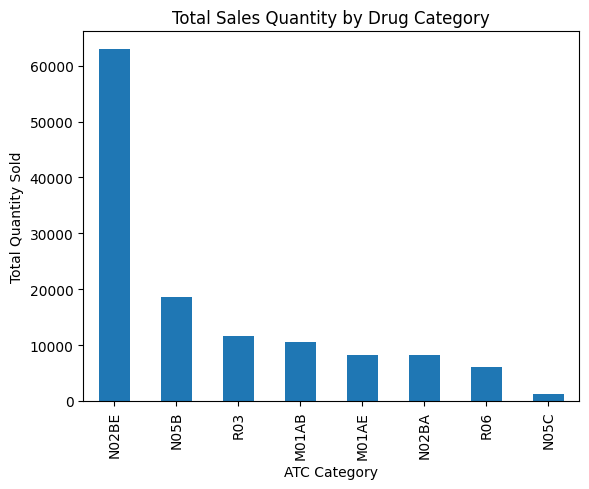

In [5]:
total_sales.plot(kind="bar")

plt.title("Total Sales Quantity by Drug Category")
plt.xlabel("ATC Category")
plt.ylabel("Total Quantity Sold")
plt.show()
print()

In [6]:
#3 Which three drugs have the highest sales in January 2015, July 2016, September 2017. 
def top3_drugs(df, year, month):
    data = df[
        (df["datum"].dt.year == year) &
        (df["datum"].dt.month == month)
    ]

    return data[drug_cols].sum().nlargest(3)
    
print("ANSWER 3")
print("January 2015")
print(top3_drugs(df, 2015, 1))
print("\nJuly 2016")
print(top3_drugs(df, 2016, 7))
print("\nSeptember 2017")
print(top3_drugs(df, 2017, 9))
print()
print()

ANSWER 3
January 2015
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

July 2016
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

September 2017
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64




In [7]:
#4 Which drug has sold the most often in 2017?
# Filter only 2017 data
data_2017 = df[df["Year"] == 2017]
# Sum sales for each drug 2017
total_2017 = data_2017[drug_cols].sum()
# Get the top-selling drug 2017
top_drug = total_2017.idxmax()
top_value = total_2017.max()
print("ANSWER 4")
print("Top selling drug in 2017:")
print(top_drug, top_value)
print()
print()
#Shows full ranking 
print("Show full sales ranking 2017")
print(total_2017.sort_values(ascending=False))
print()
print()

ANSWER 4
Top selling drug in 2017:
N02BE 9258.80483333


Show full sales ranking 2017
N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64




Answer5
Drug with highest average daily sales:
N02BE 29.917095303105413


Averge daily sales
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


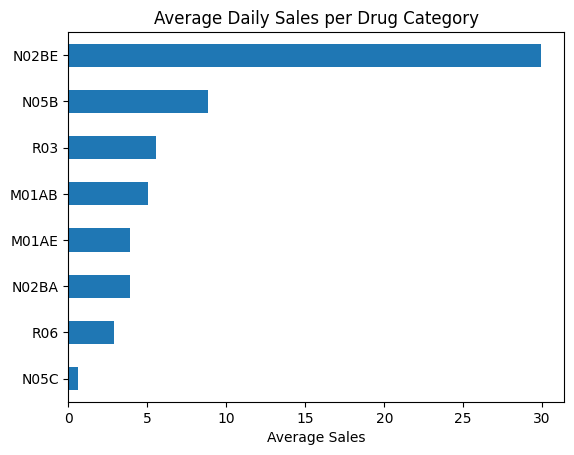

In [8]:
#5 Compute average daily sales per drug
avg_sales = df[drug_cols].mean()
# Find the highest average
top_drug = avg_sales.idxmax()
top_value = avg_sales.max()
print("Answer5")
print("Drug with highest average daily sales:")
print(top_drug, top_value)
print()
print()

print("Averge daily sales")
print(avg_sales.sort_values(ascending=False))

avg_sales.sort_values().plot(kind="barh")
plt.title("Average Daily Sales per Drug Category")
plt.xlabel("Average Sales")
plt.show()
print()
print()